In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


INPUT_PATH = Path(
    "/Users/yurujia/Desktop/Dissertation Data/final_AV_media_analysis_dataset.xlsx"
)

OUTPUT_DIR = Path(
    "/Users/yurujia/Desktop/Dissertation Data/descriptive_analysis"
)

OUTPUT_DIR.mkdir(
    exist_ok=True
)


df = pd.read_excel(INPUT_PATH)


print(df.shape)

df.head()

(1809, 12)


,title,source,date_fixed,year,month,analysis_text,topic,sentiment,country,year_month,source_id,sentiment_analysis_text
0,（财经）专访：“中德电动汽车合作远大于竞争”——访蔚来汽车董事长李斌,Xinhua,2017-06-02,2017,2017-06,在李克强总理访问德国期间，蔚来汽车５月３１日在柏林与德国大陆集团签署战略合作协议，主要涉及电...,Business and Commercialisation,1,China,NaN,NaN,NaN
1,（李克强出访配合稿）专访：务实合作始终是中德关系的基本特征——访中国驻德国公使衔参赞王卫东,Xinhua,2017-06-03,2017,2017-06,王卫东说，中德双方应“共塑创新”，构建双边关系发展新引擎。双方在智能制造、人工智能、自动驾驶...,Technology and Innovation,1,China,NaN,NaN,NaN
2,中国新能源汽车全球占比一半,Xinhua,2017-06-06,2017,2017-06,“我们正在逐渐把自动驾驶融入电动汽车这个重大专项、融入未来电动汽车产品当中。”万钢说。,Technology and Innovation,1,China,NaN,NaN,NaN
3,（科技）专家：自动驾驶技术有望让交通事故零伤亡,Xinhua,2017-06-07,2017,2017-06,吉利欧洲研发中心首席执行官方浩瀚日前在位于瑞典哥德堡的总部对新华社记者表示，未来汽车应用自动...,Safety and Risk,1,China,NaN,NaN,NaN
4,（财经）日本预计于２０２３年普及５Ｇ通信,Xinhua,2017-06-07,2017,2017-06,下一代超高速无线通信技术——第五代移动通信技术（５Ｇ）的商业使用区域预计将于２０２３年扩大至...,Technology and Innovation,1,China,NaN,NaN,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1809 entries, 0 to 1808
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   title                    1809 non-null   object        
 1   source                   1809 non-null   object        
 2   date_fixed               1809 non-null   datetime64[ns]
 3   year                     1809 non-null   int64         
 4   month                    1809 non-null   object        
 5   analysis_text            1809 non-null   object        
 6   topic                    1809 non-null   object        
 7   sentiment                1809 non-null   int64         
 8   country                  1809 non-null   object        
 9   year_month               654 non-null    object        
 10  source_id                654 non-null    float64       
 11  sentiment_analysis_text  287 non-null    object        
dtypes: datetime64[ns](1), float64(1), 

In [24]:
overview = pd.DataFrame({
    "Metric": [
        "Number of articles",
        "Number of sources",
        "Start date",
        "End date"
    ],
    "Value": [
        len(df),
        df["source"].nunique(),
        df["date_fixed"].min().date(),
        df["date_fixed"].max().date()
    ]
})


overview

,Metric,Value
0,Number of articles,1809
1,Number of sources,3
2,Start date,2017-01-03
3,End date,2026-06-24


In [25]:
source_distribution = (
    df["source"]
    .value_counts()
    .reset_index()
)


source_distribution.columns = [
    "Source",
    "Articles"
]


source_distribution

,Source,Articles
0,Xinhua,1155
1,WSJ,367
2,USA Today,287


In [26]:
source_order = [
    "Xinhua",
    "USA Today",
    "WSJ"
]


source_distribution["Source"] = pd.Categorical(
    source_distribution["Source"],
    categories=source_order,
    ordered=True
)


source_distribution = (
    source_distribution
    .sort_values("Source")
)

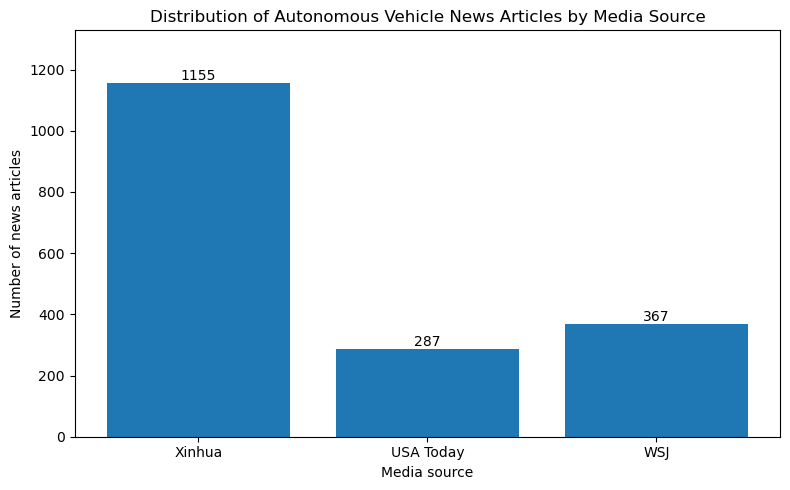

In [27]:
plt.figure(figsize=(8,5))


bars = plt.bar(
    source_distribution["Source"],
    source_distribution["Articles"]
)


plt.ylabel(
    "Number of news articles"
)

plt.xlabel(
    "Media source"
)


plt.title(
    "Distribution of Autonomous Vehicle News Articles by Media Source"
)


# 添加数量标签
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )


plt.ylim(
    0,
    source_distribution["Articles"].max()*1.15
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR/"source_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [28]:
country_distribution = (
    df["country"]
    .value_counts()
    .reset_index()
)


country_distribution.columns=[
    "Country",
    "Articles"
]


country_distribution

,Country,Articles
0,China,1155
1,USA,654


In [29]:
year_distribution = (
    df["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)


year_distribution.columns=[
    "Year",
    "Articles"
]


year_distribution

,Year,Articles
0,2017,275
1,2018,348
2,2019,288
3,2020,144
4,2021,101
5,2022,89
6,2023,142
7,2024,180
8,2025,175
9,2026,67


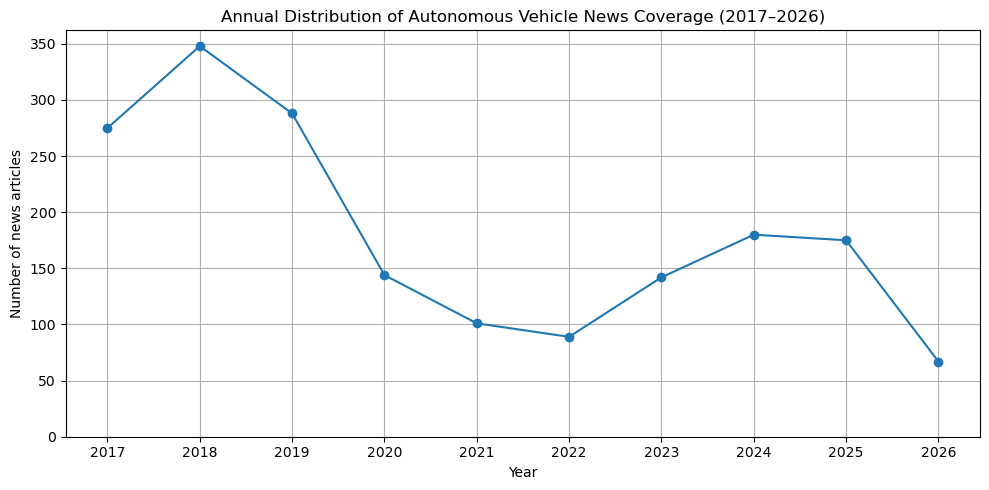

In [30]:
plt.figure(figsize=(10,5))

plt.plot(
    year_distribution["Year"],
    year_distribution["Articles"],
    marker="o"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Number of news articles"
)

plt.title(
    "Annual Distribution of Autonomous Vehicle News Coverage (2017–2026)"
)

plt.xticks(
    year_distribution["Year"]
)

plt.ylim(0)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR/"yearly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
source_year = (
    df.groupby(
        ["year","source"]
    )
    .size()
    .reset_index(name="count")
)


source_year

,year,source,count
0,2017,USA Today,103
1,2017,WSJ,81
2,2017,Xinhua,91
3,2018,USA Today,74
4,2018,WSJ,85
5,2018,Xinhua,189
6,2019,USA Today,24
7,2019,WSJ,35
8,2019,Xinhua,229
9,2020,USA Today,21


In [32]:
pivot = source_year.pivot(
    index="year",
    columns="source",
    values="count"
).fillna(0)


pivot

source,USA Today,WSJ,Xinhua
year,,,
2017,103,81,91
2018,74,85,189
2019,24,35,229
2020,21,18,105
2021,10,21,70
2022,9,28,52
2023,9,28,105
2024,7,28,145
2025,21,34,120


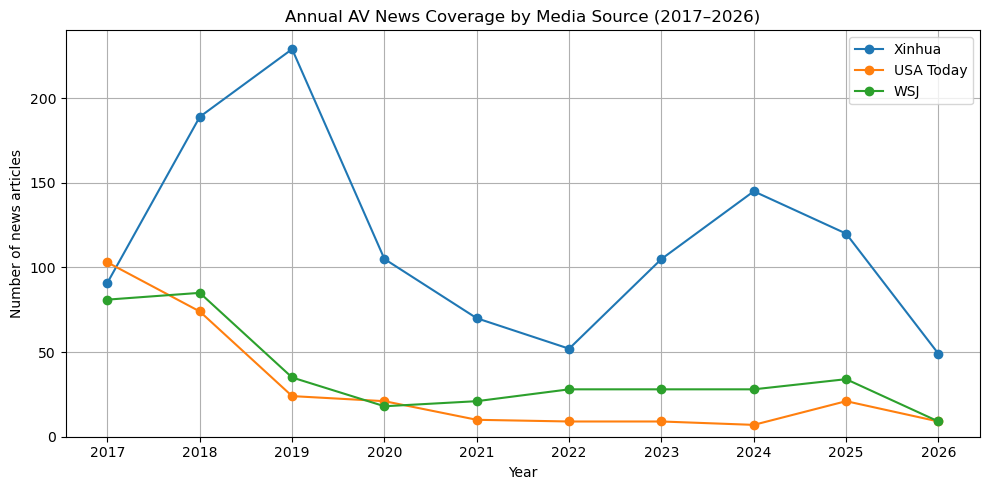

In [34]:
pivot = pivot[
    [
        "Xinhua",
        "USA Today",
        "WSJ"
    ]
]

ax = pivot.plot(
    figsize=(10,5),
    marker="o"
)


plt.xlabel(
    "Year"
)

plt.ylabel(
    "Number of news articles"
)


plt.title(
    "Annual AV News Coverage by Media Source (2017–2026)"
)


plt.xticks(
    pivot.index
)


plt.ylim(0)


plt.legend(
    title=None
)


plt.grid(True)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR/"source_year_trend.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

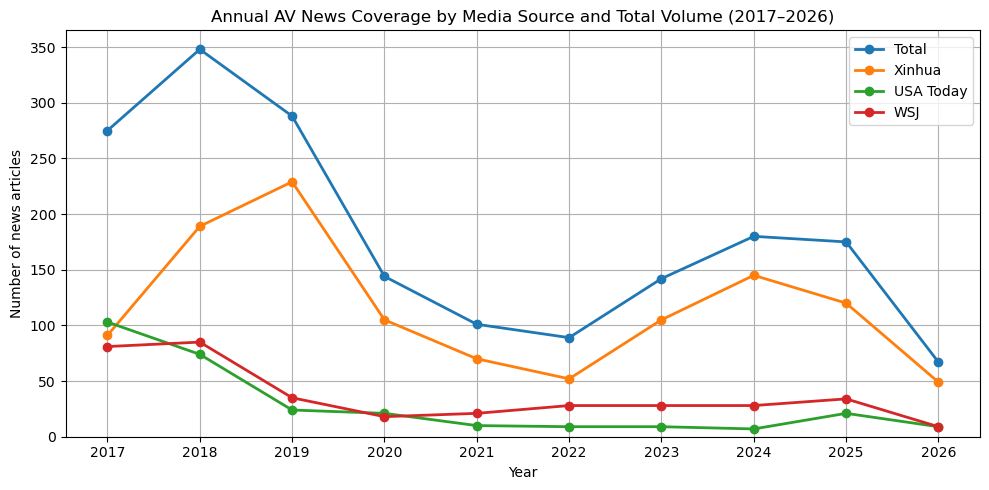

In [35]:
plot_df = pivot.copy()

plot_df["Total"] = plot_df.sum(axis=1)

plot_df = plot_df[
    [
        "Total",
        "Xinhua",
        "USA Today",
        "WSJ"
    ]
]

ax = plot_df.plot(
    figsize=(10, 5),
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Number of news articles")
plt.title("Annual AV News Coverage by Media Source and Total Volume (2017–2026)")
plt.xticks(plot_df.index)
plt.ylim(0)
plt.legend(title=None)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "source_year_trend_with_total.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()